In [1]:
using Gridap

u(x) = x[1] + x[2]
f(x) = 0

f (generic function with 1 method)

In [2]:
∇u(x) = VectorValue(1,1)

∇u (generic function with 1 method)

In [3]:
import Gridap: ∇
∇(::typeof(u)) = ∇u

gradient (generic function with 39 methods)

In [4]:
∇(u) === ∇u

true

In [5]:
domain = (0,1,0,1)
partition = (4,4)
model = CartesianDiscreteModel(domain,partition)

CartesianDiscreteModel()

In [6]:
domain3d = (0,1,0,1,0,1)
partition3d = (4,4,4)
model3d = CartesianDiscreteModel(domain3d,partition3d)

CartesianDiscreteModel()

In [9]:
writevtk(model3d,"model3d")

4-element Vector{Vector{String}}:
 ["model3d_0.vtu"]
 ["model3d_1.vtu"]
 ["model3d_2.vtu"]
 ["model3d_3.vtu"]

In [10]:
order = 1
reffe = ReferenceFE(lagrangian,Float64,order)
V0 = TestFESpace(model,reffe,conformity=:H1,dirichlet_tags="boundary")
U = TrialFESpace(V0,u)

degree = 2
Ω = Triangulation(model)
dΩ = Measure(Ω,degree)

a(u,v) = ∫( ∇(v)⊙∇(u) )*dΩ
b(v) = ∫( v*f )*dΩ

op = AffineFEOperator(a,b,U,V0)

uh = solve(op)

SingleFieldFEFunction():
 num_cells: 16
 DomainStyle: ReferenceDomain()
 Triangulation: BodyFittedTriangulation()
 Triangulation id: 12655890970943489580

In [11]:
e = u - uh

OperationCellField():
 num_cells: 16
 DomainStyle: ReferenceDomain()
 Triangulation: BodyFittedTriangulation()
 Triangulation id: 12655890970943489580

In [12]:
writevtk(Ω,"error",cellfields=["e" => e])

(["error.vtu"],)

In [13]:
el2 = sqrt(sum( ∫( e*e )*dΩ ))
eh1 = sqrt(sum( ∫( e*e + ∇(e)⋅∇(e) )*dΩ ))

1.0241643448331112e-15

In [15]:
tol = 1.e-10
@assert el2 < tol
@assert eh1 < tol

In [16]:
p = 3
u(x) = x[1]^p+x[2]^p
∇u(x) = VectorValue(p*x[1]^(p-1),p*x[2]^(p-1))
f(x) = -p*(p-1)*(x[1]^(p-2)+x[2]^(p-2))

f (generic function with 1 method)

In [17]:
∇(::typeof(u)) = ∇u
b(v) = ∫( v*f )*dΩ

b (generic function with 1 method)

In [19]:
function run(n,k)

  domain = (0,1,0,1)
  partition = (n,n)
  model = CartesianDiscreteModel(domain,partition)

  reffe = ReferenceFE(lagrangian,Float64,k)
  V0 = TestFESpace(model,reffe,conformity=:H1,dirichlet_tags="boundary")
  U = TrialFESpace(V0,u)

  degree = 2*p
  Ω = Triangulation(model)
  dΩ = Measure(Ω,degree)

  a(u,v) = ∫( ∇(v)⊙∇(u) )*dΩ
  b(v) = ∫( v*f )*dΩ

  op = AffineFEOperator(a,b,U,V0)

  uh = solve(op)

  e = u - uh

  el2 = sqrt(sum( ∫( e*e )*dΩ ))
  eh1 = sqrt(sum( ∫( e*e + ∇(e)⋅∇(e) )*dΩ ))

  (el2, eh1)

end

run (generic function with 1 method)

In [20]:
function conv_test(ns,k)

  el2s = Float64[]
  eh1s = Float64[]
  hs = Float64[]

  for n in ns

    el2, eh1 = run(n,k)
    h = 1.0/n

    push!(el2s,el2)
    push!(eh1s,eh1)
    push!(hs,h)

  end

  (el2s, eh1s, hs)

end

conv_test (generic function with 1 method)

In [21]:
el2s1, eh1s1, hs = conv_test([8,16,32,64,128],1);
el2s2, eh1s2, hs = conv_test([8,16,32,64,128],2);
nothing #hide

In [23]:
import Pkg
Pkg.add("Plots")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed LoggingExtras ──────────────── v1.2.0
   Installed LERC_jll ───────────────────── v4.0.1+0
   Installed libdecor_jll ───────────────── v0.2.2+0
   Installed Opus_jll ───────────────────── v1.5.2+0
   Installed x265_jll ───────────────────── v4.1.0+0
   Installed GR_jll ─────────────────────── v0.73.19+1
   Installed libfdk_aac_jll ─────────────── v2.0.4+0
   Installed Xorg_xkbcomp_jll ───────────── v1.4.7+0
   Installed ConcurrentUtilities ────────── v2.5.0
   Installed Grisu ──────────────────────── v1.0.2
   Installed Measures ───────────────────── v0.3.3
   Installed RelocatableFolders ─────────── v1.0.1
   Installed Xorg_xcb_util_image_jll ────── v0.4.1+0
   Installed Xorg_xcb_util_wm_jll ───────── v0.4.2+0
   Installed Contour ────────────────────── v0.6.3
   Installed PlotUtils ──────────────────── v1.4.4
   Installed RecipesPipeline ────────────── v0.6.12
   Installed Delimi

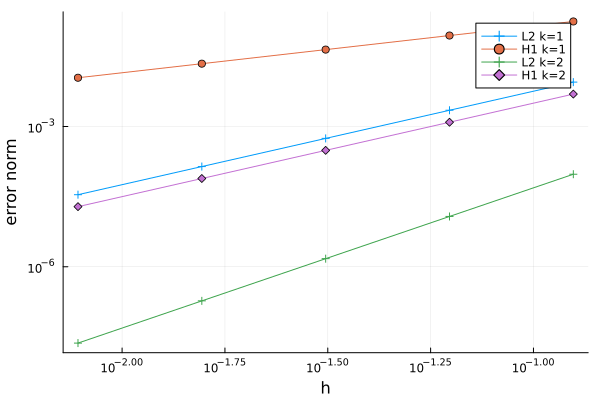

In [24]:
using Plots

plot(hs,[el2s1 eh1s1 el2s2 eh1s2],
    xaxis=:log, yaxis=:log,
    label=["L2 k=1" "H1 k=1" "L2 k=2" "H1 k=2"],
    shape=:auto,
    xlabel="h",ylabel="error norm")

In [25]:
function slope(hs,errors)
  x = log10.(hs)
  y = log10.(errors)
  linreg = hcat(fill!(similar(x), 1), x) \ y
  linreg[2]
end

slope (generic function with 1 method)

In [26]:
slope(hs,el2s1)
slope(hs,el2s2)

3.000000000212429

In [33]:
slope(hs,eh1s1)
slope(hs,eh1s2)

2.0000597414740624